In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Save model
import pickle

In [2]:
# Load dataset (adjust path if needed)
df = pd.read_csv("../dataset/cleaned_animal_disease_prediction.csv")

# Show first 5 rows
df.head()

,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Duration,...,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Prediction
0,Dog,Labrador,4,Male,25.0,Fever,Lethargy,Appetite Loss,Vomiting,3 days,...,No,No,No,No,No,No,No,39.5°C,120,Parvovirus
1,Cat,Siamese,2,Female,4.5,Coughing,Sneezing,Eye Discharge,Nasal Discharge,1 week,...,No,Yes,No,No,No,Yes,Yes,38.9°C,150,Upper Respiratory Infection
2,Cow,Holstein,3,Female,600.0,Fever,Nasal Discharge,Labored Breathing,Coughing,5 days,...,No,Yes,Yes,No,No,Yes,No,40.1°C,90,Foot and Mouth Disease
3,Dog,Beagle,1,Male,10.0,Diarrhea,Vomiting,Lethargy,Appetite Loss,2 days,...,Yes,No,No,No,No,No,No,39.2°C,130,Gastroenteritis
4,Cat,Persian,5,Male,3.8,Lethargy,Appetite Loss,Skin Lesions,No,2 weeks,...,No,No,No,No,Yes,No,No,38.7°C,160,Fungal Infection


In [3]:
# Check shape
print("Shape:", df.shape)

# Check column names
print("\nColumns:\n", df.columns)

# Check data types
print("\nData Types:\n", df.dtypes)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

Shape: (431, 22)

Columns:
 Index(['Animal_Type', 'Breed', 'Age', 'Gender', 'Weight', 'Symptom_1',
       'Symptom_2', 'Symptom_3', 'Symptom_4', 'Duration', 'Appetite_Loss',
       'Vomiting', 'Diarrhea', 'Coughing', 'Labored_Breathing', 'Lameness',
       'Skin_Lesions', 'Nasal_Discharge', 'Eye_Discharge', 'Body_Temperature',
       'Heart_Rate', 'Disease_Prediction'],
      dtype='str')

Data Types:
 Animal_Type               str
Breed                     str
Age                     int64
Gender                    str
Weight                float64
Symptom_1                 str
Symptom_2                 str
Symptom_3                 str
Symptom_4                 str
Duration                  str
Appetite_Loss             str
Vomiting                  str
Diarrhea                  str
Coughing                  str
Labored_Breathing         str
Lameness                  str
Skin_Lesions              str
Nasal_Discharge           str
Eye_Discharge             str
Body_Temperature        

In [4]:
# Convert Age like "5 days", "2 years" → numeric values

def fix_age(x):
    x = str(x).lower()
    
    if "day" in x:
        return int(x.split()[0])
    elif "month" in x:
        return int(x.split()[0]) * 30
    elif "year" in x:
        return int(x.split()[0]) * 365
    else:
        return 0

# Apply function
df["Age"] = df["Age"].apply(fix_age)

In [5]:
# Replace missing values with "None"
df = df.fillna("None")

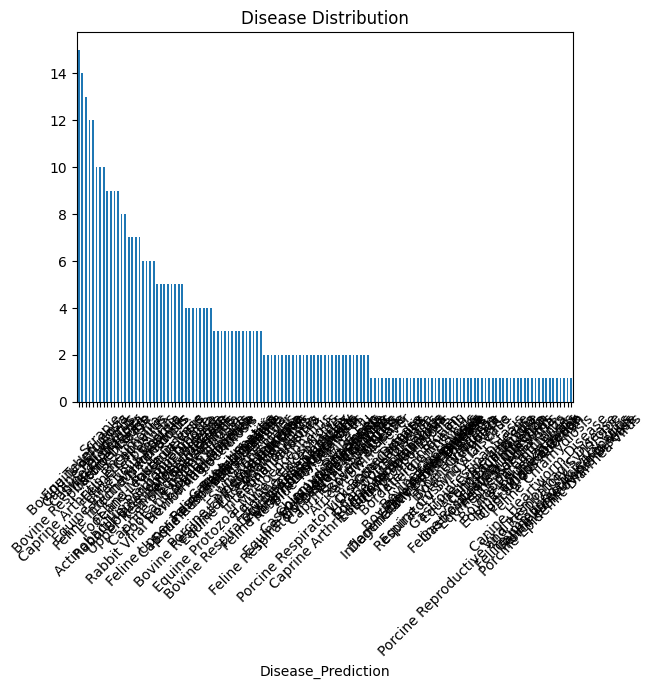

In [6]:
plt.figure()
df['Disease_Prediction'].value_counts().plot(kind='bar')
plt.title("Disease Distribution")
plt.xticks(rotation=45)
plt.show()

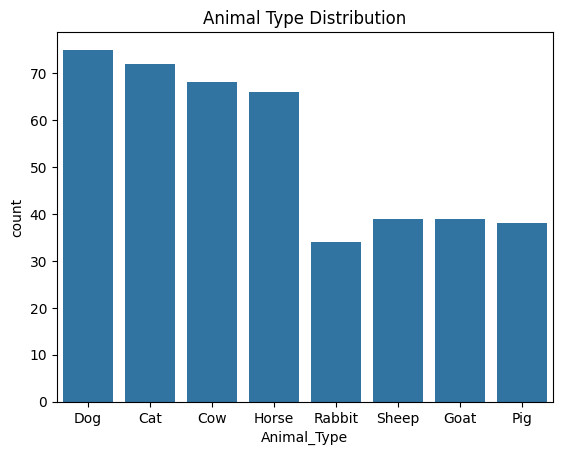

In [28]:
plt.figure()
sns.countplot(x='Animal_Type', data=df)
plt.title("Animal Type Distribution")
plt.show()

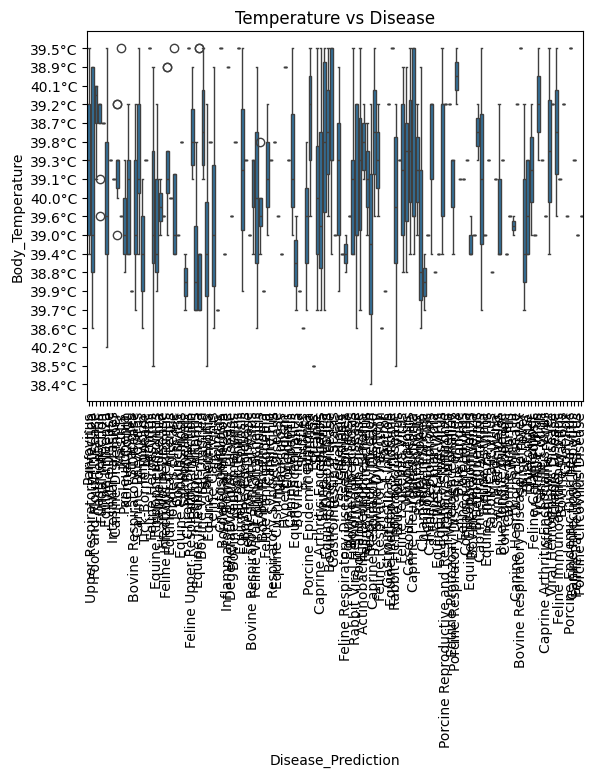

In [7]:
plt.figure()
sns.boxplot(x='Disease_Prediction', y='Body_Temperature', data=df)
plt.xticks(rotation=90)
plt.title("Temperature vs Disease")
plt.show()

In [8]:
# Convert all text columns to numeric using LabelEncoder

encoders = {}

for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

In [9]:
# Now all columns must be numeric
print(df.dtypes)

Animal_Type               str
Breed                     str
Age                     int64
Gender                    str
Weight                float64
Symptom_1                 str
Symptom_2                 str
Symptom_3                 str
Symptom_4                 str
Duration                  str
Appetite_Loss             str
Vomiting                  str
Diarrhea                  str
Coughing                  str
Labored_Breathing         str
Lameness                  str
Skin_Lesions              str
Nasal_Discharge           str
Eye_Discharge             str
Body_Temperature          str
Heart_Rate              int64
Disease_Prediction        str
dtype: object


In [10]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in df.columns:
    # ❗ Skip target column
    if col != "Disease_Prediction" and (df[col].dtype == "object" or df[col].dtype == "str"):
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

In [11]:
print(df.dtypes)

Animal_Type             int64
Breed                   int64
Age                     int64
Gender                  int64
Weight                float64
Symptom_1               int64
Symptom_2               int64
Symptom_3               int64
Symptom_4               int64
Duration                int64
Appetite_Loss           int64
Vomiting                int64
Diarrhea                int64
Coughing                int64
Labored_Breathing       int64
Lameness                int64
Skin_Lesions            int64
Nasal_Discharge         int64
Eye_Discharge           int64
Body_Temperature        int64
Heart_Rate              int64
Disease_Prediction        str
dtype: object


In [12]:
# Keep top 8 diseases
top_diseases = df["Disease_Prediction"].value_counts().head(8).index

df = df[df["Disease_Prediction"].isin(top_diseases)]

In [13]:
# 🔥 RECREATE X and y AFTER encoding
X = df.drop("Disease_Prediction", axis=1)
y = df["Disease_Prediction"]

# 🔥 SPLIT AGAIN (IMPORTANT)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
# Create models
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

# Store results
results = {}

# Train each model
for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print("\n", name)
    print("Accuracy:", acc)


 Random Forest
Accuracy: 0.75

 Decision Tree
Accuracy: 0.75

 Logistic Regression
Accuracy: 0.65


/home/harshrajsingh035/animal-disease-prediction/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


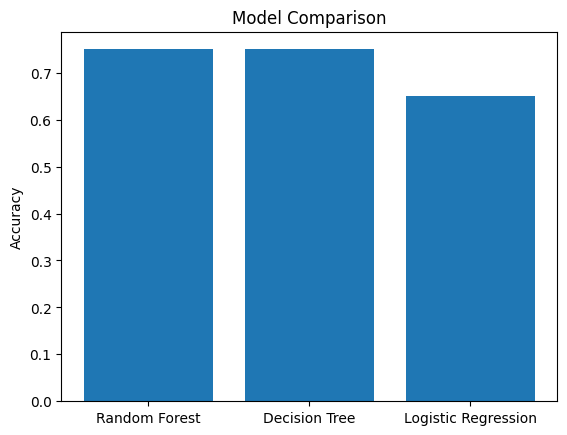

In [15]:
# Plot accuracy comparison
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [16]:
# Separate target
y = df["Disease_Prediction"]

# Features
X = df.drop("Disease_Prediction", axis=1)

# One-hot encoding
X = pd.get_dummies(X)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train better model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, max_depth=10)
model.fit(X_train, y_train)

# Accuracy
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.55


In [17]:
print(y.nunique())

8


In [18]:
best_model = models["Random Forest"]

print("✅ Final Model Selected: Random Forest")

✅ Final Model Selected: Random Forest


In [19]:
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.55


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pickle
import os

# ❌ DO NOT use LabelEncoder
# Keep y as original disease names

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Save
os.makedirs("../backend", exist_ok=True)

pickle.dump(model, open("../backend/animal_disease_model.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("../backend/columns.pkl", "wb"))

print("✅ Model saved (simple version)")

✅ Model saved (simple version)


In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

# Parameters
DATASET_DIR = '../dataset'  # Folder jahan hamari 4 categories ki images hain
BATCH_SIZE = 32
IMG_SIZE = (224, 224)       # Model ko saari images ek hi size ki chahiye

print("Loading Data...")
# Training ke liye images load kar rahe hain (80% seekhne ke liye)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Validation ke liye images (20% test karne ke liye ki model sahi seekh raha hai ya nahi)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print("Categories Found:", class_names)

Loading Data...
Found 170 files belonging to 4 classes.
Using 136 files for training.
Found 170 files belonging to 4 classes.
Using 34 files for validation.
Categories Found: ['Fever', 'Healthy', 'Injury', 'Skin_Infection']


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [12]:
# Image ko -1 se 1 ke scale par set karna (Normalization)
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# Google ka pre-trained model la rahe hain
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = False  # Abhi ke liye iske purane dimaag ko lock kar rahe hain

# Apna custom model banana (Jo sirf 4 bimariyaan pehchane)
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x) # Overfitting rokne ke liye
outputs = tf.keras.layers.Dense(4, activation='softmax')(x) # 4 bimariyon ke liye output layer

model = tf.keras.Model(inputs, outputs)

# Model ko compile karna (Sikhane ka tareeqa)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
EPOCHS = 10  # Model 10 baar saari images ko dekhega

print("Training Shuru ho rahi hai... Kripya thoda wait karein ☕")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)
print("Training Complete! 🎉")

Training Shuru ho rahi hai... Kripya thoda wait karein ☕
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 523ms/step - accuracy: 0.8750 - loss: 0.4911 - val_accuracy: 0.5588 - val_loss: 1.1460
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 524ms/step - accuracy: 0.8603 - loss: 0.4848 - val_accuracy: 0.5588 - val_loss: 1.1322
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 521ms/step - accuracy: 0.9044 - loss: 0.4355 - val_accuracy: 0.6176 - val_loss: 1.1149
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 517ms/step - accuracy: 0.9044 - loss: 0.4094 - val_accuracy: 0.6176 - val_loss: 1.1008
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 538ms/step - accuracy: 0.9338 - loss: 0.3842 - val_accuracy: 0.6471 - val_loss: 1.0931
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 562ms/step - accuracy: 0.8971 - loss: 0.3421 - val_accuracy: 0.6471 - val_loss: 1.1036
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 558ms/step - accuracy: 0.9338 - loss: 0.3109 - val_accuracy: 0.6471 - val_loss: 1.1120
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 568ms/step - accuracy:

In [15]:
# 1. Model Save Karein
model.save('../backend/animal_disease_model.keras')
print("Model Saved Successfully in backend folder!")

# 2. Class names (Labels) save karein taaki server ko pata ho kiska matlab kya hai
with open('../backend/class_names.pkl', 'wb') as f:
    pickle.dump(class_names, f)
print("Class labels saved!")

Model Saved Successfully in backend folder!
Class labels saved!
